# Analytical Groundwater Modeling — Exercises 1.1 to 1.3
**Chapter 1: Steady One-Dimensional Flow**
##### A.A.Aliyu - 6613535

Solution to Exercises 1.2 and 1.3 from *Analytical Groundwater Modeling* (Mark Bakker & Vincent Post, 2022).
---
## Background
We consider **areal recharge between two parallel rivers** that fully penetrate an unconfined aquifer of constant transmissivity $T = kH$.
### Governing equations
The **head solution** (Eq. 1.24):
$$h = -\frac{N}{2T}(x^2 - Lx) + \frac{(h_L - h_0)x}{L} + h_0$$

The **discharge vector** (Eq. 1.25):
$$Q_x = N\left(x - \frac{L}{2}\right) - T\frac{h_L - h_0}{L}$$

Boundary conditions:
- $h|_{x=0} = h_0$
- $h|_{x=L} = h_L$

---

## Exercise 1.2 — Left River Head for Zero Left-to-Right Flow

### Problem statement
> *Determine what the water level in the left river must be so that exactly all water
> that infiltrates flows to the right river, while no water from the left river flows to
> the right river. Plot h and Qx vs. x.*

### Theory

The condition **"all recharge flows right, none flows left"** means:

- The water divide sits exactly at $x^* = 0$ (the left boundary).
- $Q_x(0) = 0$: the discharge at $x = 0$ is zero — no flow enters or leaves through the left river.

Setting $Q_x = 0$ at $x = 0$ in Eq. 1.25:

$$0 = N\left(0 - \frac{L}{2}\right) - T\frac{h_L - h_0}{L}$$

$$\frac{T(h_0 - h_L)}{L} = \frac{NL}{2}$$

$$\boxed{h_0 = h_L + \frac{NL^2}{2T}}$$

In [37]:
import numpy as np, matplotlib.pyplot as plt
L=1000; H=10; k=10; n=0.3; T=k*H; h0=6; hL=4; N=0.001
x = np.linspace(0, L, 500)

# ── Required h0 for divide at x = 0 ──────────────────────────
h0_ex2 = hL + N * L**2 / (2 * T)
print(f'Required left river head  h0 = {h0_ex2:.4f} m')
# ── Solution ──────────────────────────────────────────────────
h_ex2  = -N / (2*T) * (x**2 - L*x) + (hL - h0_ex2) * x / L + h0_ex2
Qx_ex2 = N * (x - L/2) - T * (hL - h0_ex2) / L

# ── Verify ────────────────────────────────────────────────────
print(f'\n for_Verification:')
print(f'  Qx at x = 0  : {Qx_ex2[0]:.6f} m²/d  (should be ≈ 0)')
print(f'  Qx at x = L  : {Qx_ex2[-1]:.4f} m²/d  (should equal N·L = {N*L:.4f} m²/d)')
print(f'  Water divide  : x* = L/2 + T(hL-h0)/(NL) = {L/2 + T*(hL - h0_ex2)/(N*L):.1f} m')

Required left river head  h0 = 9.0000 m

 for_Verification:
  Qx at x = 0  : 0.000000 m²/d  (should be ≈ 0)
  Qx at x = L  : 1.0000 m²/d  (should equal N·L = 1.0000 m²/d)
  Water divide  : x* = L/2 + T(hL-h0)/(NL) = 0.0 m


### Exercise 1.2

The required left-river head is:

$$h_0 = h_L + \frac{NL^2}{2T} = 4 + \frac{0.001 \times 1000^2}{2 \times 100} = 4 + 5 = \mathbf{9\text{ m}}$$

**Interpretation:** With $h_0 = 9$ m, the head gradient from the left river is exactly steep enough  
that the leftward pressure from the high water table is balanced by the rightward pull from the  
lower right river. The water divide sits at $x = 0$, so $Q_x(0) = 0$: the left river neither  
supplies water to nor receives water from the aquifer. All recharge ($NL = 1$ m²/d) exits through  
the right river.

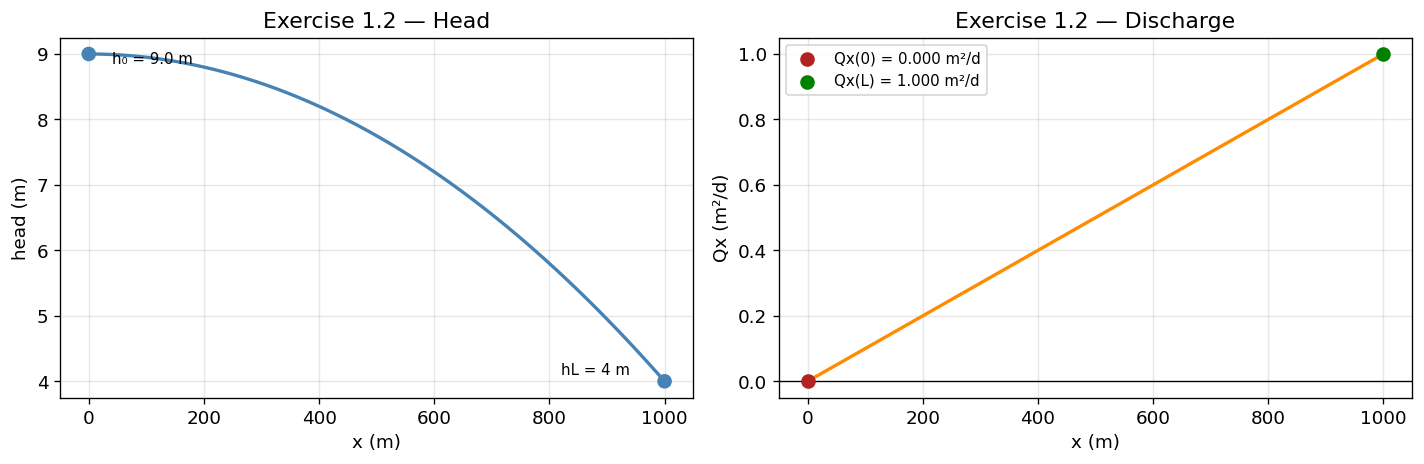

Figure saved.


In [38]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

# ── Head ──────────────────────────────────────────────────────
ax1.plot(x, h_ex2, 'steelblue', lw=2)
ax1.scatter([0, L], [h0_ex2, hL], color=['steelblue','steelblue'], zorder=5, s=60)
ax1.annotate(f'h₀ = {h0_ex2:.1f} m', (0, h0_ex2), xytext=(40, h0_ex2 - 0.15), fontsize=9)
ax1.annotate(f'hL = {hL} m', (L, hL), xytext=(820, hL + 0.1), fontsize=9)
ax1.set_xlabel('x (m)'); ax1.set_ylabel('head (m)')
ax1.set_title('Exercise 1.2 — Head'); ax1.grid(alpha=0.3)

# ── Discharge ─────────────────────────────────────────────────
ax2.plot(x, Qx_ex2, 'darkorange', lw=2)
ax2.axhline(0, color='k', lw=0.8)
ax2.scatter([0], [Qx_ex2[0]], color='firebrick', zorder=5, s=60,
            label=f'Qx(0) = {Qx_ex2[0]:.3f} m²/d')
ax2.scatter([L], [Qx_ex2[-1]], color='green', zorder=5, s=60,
            label=f'Qx(L) = {Qx_ex2[-1]:.3f} m²/d')
ax2.set_xlabel('x (m)'); ax2.set_ylabel('Qx (m²/d)')
ax2.set_title('Exercise 1.2 — Discharge')
ax2.legend(fontsize=9); ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()
print('Figure saved.')

---

## Exercise 1.3 — Infer Areal Recharge from an Interior Head Measurement

### Problem statement
> *Consider the case that $h_0 = h_L = 10$ m. The head halfway between the two rivers  
> is measured to be 9 m. Compute the areal recharge for this case using the parameters  
> of the example above. Plot h vs. x.*

### Theory

With **equal** river heads ($h_0 = h_L = \hat{h}$), the linear gradient term vanishes:

$$h = -\frac{N}{2T}(x^2 - Lx) + \hat{h}$$

At the midpoint $x = L/2$, $(x^2 - Lx) = \frac{L^2}{4} - \frac{L^2}{2} = -\frac{L^2}{4}$, so:

$$h\!\left(\frac{L}{2}\right) = \frac{N L^2}{8T} + \hat{h}$$

Solving for $N$:

$$\boxed{N = \frac{8T}{L^2}\left[h\!\left(\frac{L}{2}\right) - \hat{h}\right]}$$

**Physical note:** If $h(L/2) < \hat{h}$, then $N < 0$, which represents **net evapotranspiration**  
(groundwater is being extracted from the aquifer by plants/evaporation faster than it recharges).

In [39]:
# ── base parameters (repeated so this cell runs standalone) ──
import numpy as np, matplotlib.pyplot as plt
L=1000; H=10; k=10; n=0.3; T=k*H
x = np.linspace(0, L, 500)
# ── Infer N ───────────────────────────────────────────────────
N_ex3 = 8 * T / L**2 * (h_mid - h0_ex3)
print(f'Inferred areal recharge  N = {N_ex3:.4f} m/d')

# ── Exercise 1.3 parameters ───────────────────────────────────
h0_ex3  = 10.0   # head at left  river [m]
hL_ex3  = 10.0   # head at right river [m]  (equal rivers)
h_mid   =  9.0   # measured head at x = L/2 [m]

# ── Solution ──────────────────────────────────────────────────
h_ex3  = -N_ex3 / (2*T) * (x**2 - L*x) + (hL_ex3 - h0_ex3) * x / L + h0_ex3
Qx_ex3 = N_ex3 * (x - L/2) - T * (hL_ex3 - h0_ex3) / L

Inferred areal recharge  N = -0.0008 m/d


### Exercise 1.3

$$N = \frac{8T}{L^2}\left(h_{\text{mid}} - \hat{h}\right) = \frac{8 \times 100}{1{,}000{,}000}(9 - 10) = -0.0008 \text{ m/d} $$

**The negative sign indicates net evapotranspiration**, not recharge.  
The aquifer loses water to the atmosphere faster than precipitation replenishes it.  
Because both river heads are equal, the flow field is **symmetric** about $x = L/2$:  
half the extracted groundwater is supplied by the left river, half by the right.

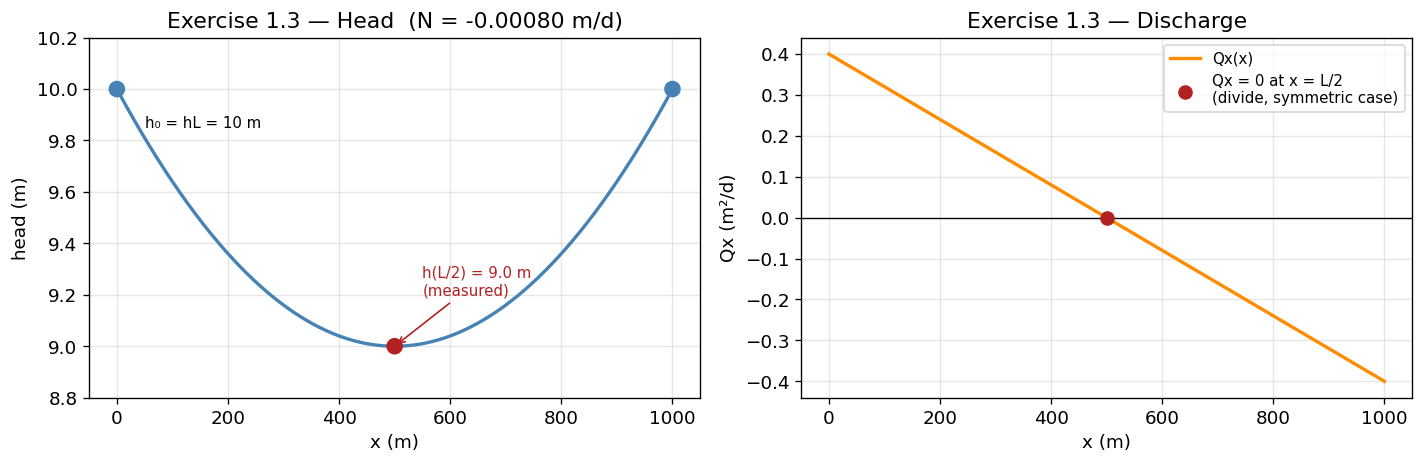

Figure saved.


In [40]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

# ── Head ──────────────────────────────────────────────────────
ax1.plot(x, h_ex3, 'steelblue', lw=2, label='h(x)')
ax1.scatter([0, L/2, L], [h0_ex3, h_mid, hL_ex3],
            color=['steelblue', 'firebrick', 'steelblue'],
            zorder=5, s=80,
            label=['River heads', 'Measured midpoint', ''])
ax1.annotate(f'h(L/2) = {h_mid} m\n(measured)', xy=(L/2, h_mid),
             xytext=(550, 9.2), fontsize=9, color='firebrick',
             arrowprops=dict(arrowstyle='->', color='firebrick'))
ax1.annotate(f'h₀ = hL = {h0_ex3:.0f} m', xy=(0, h0_ex3),
             xytext=(50, 9.85), fontsize=9)
ax1.set_xlabel('x (m)'); ax1.set_ylabel('head (m)')
ax1.set_title(f'Exercise 1.3 — Head  (N = {N_ex3:.5f} m/d)')
ax1.set_ylim(8.8, 10.2); ax1.grid(alpha=0.3)

# ── Discharge ─────────────────────────────────────────────────
ax2.plot(x, Qx_ex3, 'darkorange', lw=2, label='Qx(x)')
ax2.axhline(0, color='k', lw=0.8)
ax2.scatter([L/2], [0], color='firebrick', zorder=5, s=60,
            label=f'Qx = 0 at x = L/2\n(divide, symmetric case)')
ax2.set_xlabel('x (m)'); ax2.set_ylabel('Qx (m²/d)')
ax2.set_title('Exercise 1.3 — Discharge')
ax2.legend(fontsize=9); ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()
print('Figure saved.')

---
## Key Equations Reference

| Quantity | Formula |
|---|---|
| Head | $h = -\dfrac{N}{2T}(x^2 - Lx) + \dfrac{(h_L-h_0)x}{L} + h_0$ |
| Discharge | $Q_x = N\!\left(x - \dfrac{L}{2}\right) - T\dfrac{h_L - h_0}{L}$ |
| Water divide | $x^* = \dfrac{L}{2} + \dfrac{T(h_L - h_0)}{NL}$ |
| $h_0$ for zero left outflow | $h_0 = h_L + \dfrac{NL^2}{2T}$ |
| Infer $N$ from $h(L/2)$ | $N = \dfrac{8T}{L^2}\!\left[h(L/2) - h_0\right]$ (when $h_0 = h_L$) |